# EC Extrapolation to non-zero $\phi$ with stats

In [1]:
from dvr import *
import random

In [2]:
seed = 1

random.seed(seed)
np.random.seed(seed)

In [3]:
# define system parameters
n = 256                      # number of DVR grid points
n_ecsystems = 128            # number of EC computations per phi
k = 1                        # number of states to sample per phi
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

save_plots = True           # save plots or not

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [4]:
# compute exact data
phi_predict = np.linspace(pi/24, pi/6, 5)

test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
exact_energies, exact_rrs = [], []
for phi in phi_predict:
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=True)
    exact_energies.append(eigval[0])
    exact_rrs.append(rr)

# compute training data
phi_training_range, num_phi_points = [pi/24, pi/6], 20

train_energies, train_rrs = [], []
for phi in np.linspace(phi_training_range[0], phi_training_range[1], 20):
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=True)
    train_energies.append(eigval[0])
    train_rrs.append(rr)

In [5]:
# construct EC ensemble and train all ECs
EC_ensemble = ECEnsemble(n_ecsystems, n, L, real_res, potential=gauss_s)
EC_ensemble.train(phi_training_range, num_phi_points, k)
EC_ensemble.construct_bases()

# predict energies, <r^2> and <r^2> IQR
predict_energies, predict_rrs, \
    predict_rrs_err95, predict_rrs_err68, \
    predict_energies_err95, predict_energies_err68 = EC_ensemble.extrapolate(phi_predict, rotate_rr=True)

In [8]:
# get maximum error bands for radius and energy measurements across many phi

# average the median rrs and energies over all phi
avg_real_rr = np.mean(np.real(predict_rrs))
avg_imag_rr = np.mean(np.imag(predict_rrs))
avg_real_energy = np.mean(np.real(predict_energies))
avg_imag_energy = np.mean(np.imag(predict_energies))

# grab maximum 95% intervals for radius measurements
max_real_rr_err = max(
    np.max(np.abs(np.real(predict_rrs_err95[0]))),
    np.max(np.abs(np.real(predict_rrs_err95[1])))
)

max_imag_rr_err = max(
    np.max(np.abs(np.imag(predict_rrs_err95[0]))),
    np.max(np.abs(np.imag(predict_rrs_err95[1])))
)

# grab maximum 95% intervals for energy measurements
max_real_energy_err = max(
    np.max(np.abs(np.real(predict_energies_err95[0]))),
    np.max(np.abs(np.real(predict_energies_err95[1])))
)

max_imag_energy_err = max(
    np.max(np.abs(np.imag(predict_energies_err95[0]))),
    np.max(np.abs(np.imag(predict_energies_err95[1])))
)

print(
    f"<r^2> = "
    f"({avg_real_rr:.6f} ± {max_real_rr_err:.6f}) "
    f"+ i({avg_imag_rr:.6f} ± {max_imag_rr_err:.6f})"
)

print(
    f"E = "
    f"({avg_real_energy:.6f} ± {max_real_energy_err:.6f}) "
    f"+ i({avg_imag_energy:.6f} ± {max_imag_energy_err:.6f})"
)

<r^2> = (0.773978 ± 0.001423) + i(0.199376 ± 0.001395)
E = (1.605689 ± 0.000003) + i(-0.046589 ± 0.000002)


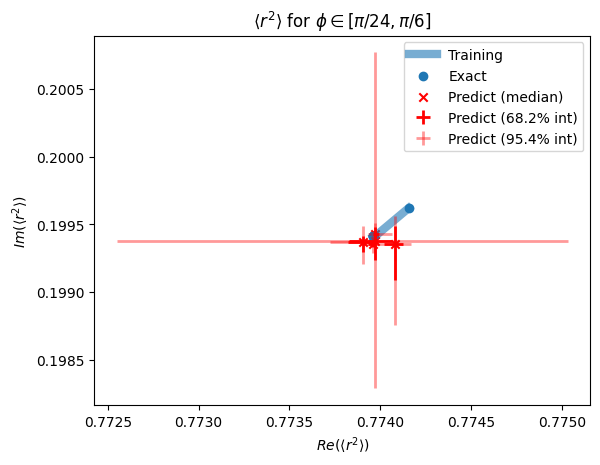

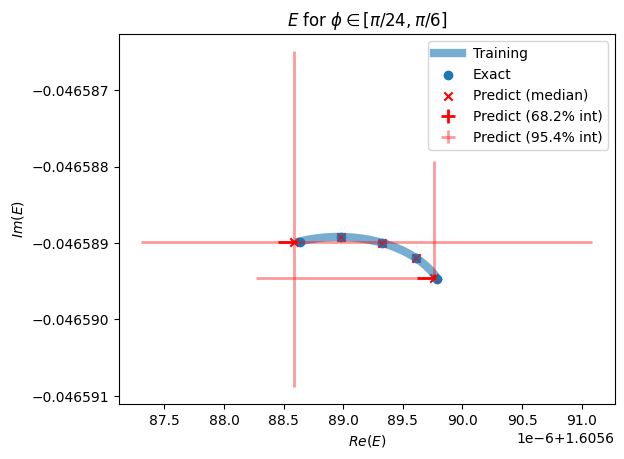

In [7]:
# plot results with error bands
fig, ax = plt.subplots()
ax.plot(np.real(train_rrs), np.imag(train_rrs), linewidth=6, alpha=0.6, label="Training")
#ax.set_aspect('equal')
ax.scatter(np.real(exact_rrs), np.imag(exact_rrs), label="Exact")
ax.scatter(np.real(predict_rrs), np.imag(predict_rrs), c='red', marker='x', label="Predict (median)")
ax.errorbar(np.real(predict_rrs), np.imag(predict_rrs),
            yerr=(np.imag(predict_rrs_err68[0]), np.imag(predict_rrs_err68[1])),
            xerr=(np.real(predict_rrs_err68[0]), np.real(predict_rrs_err68[1])),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax.errorbar(np.real(predict_rrs), np.imag(predict_rrs),
            yerr=(np.imag(predict_rrs_err95[0]), np.imag(predict_rrs_err95[1])),
            xerr=(np.real(predict_rrs_err95[0]), np.real(predict_rrs_err95[1])),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=.4, label='Predict (95.4% int)')
ax.set_xlabel(r"$Re(\langle r^2 \rangle)$")
ax.set_ylabel(r"$Im(\langle r^2 \rangle)$")
ax.set_title(r"$\langle r^2\rangle$ for $\phi\in [\pi/24,\pi/6]$")
ax.legend()
if save_plots:
    plt.savefig("./plots/ec_radius_stats.png")
plt.show()

fig, ax = plt.subplots()
#ax.set_aspect('equal')
ax.plot(np.real(train_energies), np.imag(train_energies), linewidth=6, alpha=0.6, label=r"Training")
ax.scatter(np.real(exact_energies), np.imag(exact_energies), label="Exact")
ax.scatter(np.real(predict_energies), np.imag(predict_energies), c='red', marker='x', label="Predict (median)")
ax.errorbar(np.real(predict_energies), np.imag(predict_energies),
            yerr=(np.imag(predict_energies_err68[0]), np.imag(predict_energies_err68[1])),
            xerr=(np.real(predict_energies_err68[0]), np.real(predict_energies_err68[1])),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax.errorbar(np.real(predict_energies), np.imag(predict_energies),
            yerr=(np.imag(predict_energies_err95[0]), np.imag(predict_energies_err95[1])),
            xerr=(np.real(predict_energies_err95[0]), np.real(predict_energies_err95[1])),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=.4, label='Predict (95.4% int)')
ax.set_xlabel(r"$Re(E)$")
ax.set_ylabel(r"$Im(E)$")
ax.set_title(r"$E$ for $\phi\in [\pi/24,\pi/6]$")
ax.legend()
if save_plots:
    plt.savefig("./plots/ec_energy_stats.png")
plt.show()